In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ML y NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix
from rapidfuzz.distance import JaroWinkler

# Deep Learning
import torch
from transformers import AutoTokenizer, DistilBertTokenizer
from sentence_transformers import SentenceTransformer
import faiss

import warnings
warnings.filterwarnings('ignore')

today = datetime.today().strftime('%Y-%m-%d')
OUTPUT_FOLDER = 'blocking_benchmark_results'
GROUND_TRUTH_PATH = 'final_ground_truth.jsonl'
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

In [2]:
def prepare_benchmark_from_jsonl(gt_path):
    positives = set()
    entities_dict = {}
    
    with open(gt_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines:
            record = json.loads(line)
            
            id1 = str(record.get('RIAD_CD_1', '')).strip()
            id2 = str(record.get('RIAD_CD_2', '')).strip()
            
            # --- Entity 1 ---
            if id1 and id1 not in entities_dict:
                entities_dict[id1] = {
                    'entty_riad_cd': id1,
                    'nm_entty': str(record.get('NM_ENTTY_1', '')).strip(),
                    'cty': str(record.get('CTY_1', '')).strip(),
                    'strt': str(record.get('STRT_1', '')).strip(),
                    'pstl_cd': str(record.get('PSTL_CD_1', '')).strip(),
                    'cntry': id1[:2]
                }
                
            # --- Entity 2 ---
            if id2 and id2 not in entities_dict:
                entities_dict[id2] = {
                    'entty_riad_cd': id2,
                    'nm_entty': str(record.get('NM_ENTTY_2', '')).strip(),
                    'cty': str(record.get('CTY_2', '')).strip(),
                    'strt': str(record.get('STRT_2', '')).strip(),
                    'pstl_cd': str(record.get('PSTL_CD_2', '')).strip(),
                    'cntry': id2[:2]
                }
    
            if record.get('ASSESSMENT') == 'y':
                if id1 and id2:
                    positives.add(tuple(sorted([id1, id2])))
                    
    df_universe = pd.DataFrame(list(entities_dict.values()))
    
    # Blocking key
    df_universe['blocking_text'] = df_universe['nm_entty'].str.lower().str.strip() # + ' ' + df_universe['strt'].str.lower().str.strip() + ' ' + df_universe['cty'].str.lower().str.strip()
    
    print(f"   > Total candidate pairs: {len(lines)}")
    print(f"   > Total unique entities: {len(df_universe)}")
    print(f"   > Total True Positives (Duplicates): {len(positives)}")
    
    return df_universe, positives

df_all, gt_positives = prepare_benchmark_from_jsonl(GROUND_TRUTH_PATH)
COUNTRIES = df_all['cntry'].unique()

   > Total candidate pairs: 116749
   > Total unique entities: 83236
   > Total True Positives (Duplicates): 15011


In [3]:
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
auto_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

device = "cuda" if torch.cuda.is_available() else "cpu"
bi_encoder_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2').to(device)
print(f"Loading model. Device:: {device.upper()}")

# ==========================================
# 1. TF-IDF Char N-Grams
# ==========================================
def run_tfidf_char_blocking(group_df, top_k=10, threshold=0.8):
    if len(group_df) < 2: return []
    vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 3), min_df=1)
    try: tfidf_matrix = vectorizer.fit_transform(group_df['blocking_text'])
    except ValueError: return []

    nbrs = NearestNeighbors(n_neighbors=min(top_k + 1, len(group_df)), n_jobs=-1, metric='cosine').fit(tfidf_matrix)
    distances, indices = nbrs.kneighbors(tfidf_matrix)

    results = []
    for i in range(indices.shape[0]):
        for j, neighbor_idx in enumerate(indices[i]):
            if i == neighbor_idx: continue
            score = 1 - distances[i][j]
            if score < threshold: continue
            row_left = group_df.iloc[i]
            row_right = group_df.iloc[neighbor_idx]
            lid = row_left['entty_riad_cd']
            rid = row_right['entty_riad_cd']
            if lid >= rid: continue
            results.append({
                'id_1': lid,
                'id_2': rid,
                'nm_entty_1': row_left['nm_entty'],
                'nm_entty_2': row_right['nm_entty'],
                'cty_1': row_left['cty'],
                'cty_2': row_right['cty'],
                'strt_1': row_left['strt'],
                'strt_2': row_right['strt'],
                'pstl_cd_1': row_left['pstl_cd'],
                'pstl_cd_2': row_right['pstl_cd'],
                'cntry_1': row_left['cntry'],
                'cntry_2': row_right['cntry'],
                'score': score
            })
    return results

# ==========================================
# 2. TF-IDF Matrix Tokenization (DistilBERT)
# ==========================================
def bert_tokenize(text): return distilbert_tokenizer.tokenize(text)

def run_tfidf_bert_blocking(group_df, top_k=10, threshold=0.85):
    if len(group_df) < 2: return []
    vectorizer = TfidfVectorizer(analyzer='word', tokenizer=bert_tokenize, token_pattern=None, min_df=1)
    try: tfidf_matrix = vectorizer.fit_transform(group_df['blocking_text'])
    except ValueError: return []

    nbrs = NearestNeighbors(n_neighbors=min(top_k + 1, len(group_df)), n_jobs=-1, metric='cosine').fit(tfidf_matrix)
    distances, indices = nbrs.kneighbors(tfidf_matrix)

    results = []
    for i in range(indices.shape[0]):
        for j, neighbor_idx in enumerate(indices[i]):
            if i == neighbor_idx: continue
            score = 1 - distances[i][j]
            if score < threshold: continue
            row_left = group_df.iloc[i]
            row_right = group_df.iloc[neighbor_idx]
            lid = row_left['entty_riad_cd']
            rid = row_right['entty_riad_cd']
            if lid >= rid: continue
            results.append({
                'id_1': lid,
                'id_2': rid,
                'nm_entty_1': row_left['nm_entty'],
                'nm_entty_2': row_right['nm_entty'],
                'cty_1': row_left['cty'],
                'cty_2': row_right['cty'],
                'strt_1': row_left['strt'],
                'strt_2': row_right['strt'],
                'pstl_cd_1': row_left['pstl_cd'],
                'pstl_cd_2': row_right['pstl_cd'],
                'cntry_1': row_left['cntry'],
                'cntry_2': row_right['cntry'],
                'score': score
            })
    return results

# ==========================================
# 3. Smart Blocking (DistilBERT - Cosine + JaroWinkler)
# ==========================================
def get_distilbert_indicators(df, text_col):
    texts = df[text_col].astype(str).tolist()
    data, row, col = [], [], []
    encodings = auto_tokenizer(texts, add_special_tokens=False, truncation=True, max_length=512)
    for i, token_ids in enumerate(encodings['input_ids']):
        unique_tokens = sorted(list(set(token_ids)))
        if not unique_tokens: continue
        n_tokens = len(unique_tokens)
        data.extend([1] * n_tokens)
        row.extend([i] * n_tokens)
        col.extend(unique_tokens)
    return csr_matrix((data, (row, col)), shape=(len(texts), auto_tokenizer.vocab_size), dtype=np.float32)

def run_smart_blocking(group_df, top_k=10, min_cosine=0.4, min_jaro=0.85):
    if len(group_df) < 2: return []
    indicators_norm = normalize(get_distilbert_indicators(group_df, 'blocking_text'), norm='l2', axis=1)
    results = []
    
    for i in range(indicators_norm.shape[0]):
        cosine_scores = indicators_norm[i, :].dot(indicators_norm.transpose()).toarray()[0]
        candidate_indices = np.where(cosine_scores >= min_cosine)[0]
        candidate_indices = candidate_indices[candidate_indices > i] 
        
        if len(candidate_indices) > top_k * 2:
             top_k_indices = np.argpartition(cosine_scores[candidate_indices], -top_k*2)[-top_k*2:]
             best_indices = candidate_indices[top_k_indices]
        else: best_indices = candidate_indices

        lname = group_df.iloc[i]['nm_entty']

        row_left = group_df.iloc[i]
        lid = row_left['entty_riad_cd']
        
        for neighbor_idx in best_indices:
            rname = group_df.iloc[neighbor_idx]['nm_entty']
            jw_score = 1.0 - JaroWinkler.distance(lname, rname)
            if jw_score < min_jaro: continue
            row_right = group_df.iloc[neighbor_idx]
            rid = row_right['entty_riad_cd']
            results.append({
                'id_1': lid,
                'id_2': rid,
                'nm_entty_1': row_left['nm_entty'],
                'nm_entty_2': row_right['nm_entty'],
                'cty_1': row_left['cty'],
                'cty_2': row_right['cty'],
                'strt_1': row_left['strt'],
                'strt_2': row_right['strt'],
                'pstl_cd_1': row_left['pstl_cd'],
                'pstl_cd_2': row_right['pstl_cd'],
                'cntry_1': row_left['cntry'],
                'cntry_2': row_right['cntry'],
                'score': jw_score
            })
            
    return results

# ==========================================
# 4. Neural Bi-Encoder (FAISS Exact)
# ==========================================
def run_neural_exact(group_df, top_k=10, min_score=0.6):
    if len(group_df) < 2: return []
    texts = group_df['blocking_text'].astype(str).tolist()
    ids = group_df['entty_riad_cd'].tolist()
    
    embeddings = bi_encoder_model.encode(texts, batch_size=64, show_progress_bar=False, convert_to_numpy=True, normalize_embeddings=True)
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)
    D, I = index.search(embeddings, top_k + 1)
    
    results = []
    for i in range(len(texts)):
        for j, neighbor_idx in enumerate(I[i]):
            if i == neighbor_idx: continue
            if D[i][j] < min_score: continue
            if neighbor_idx <= i: continue
            row_left = group_df.iloc[i]
            row_right = group_df.iloc[neighbor_idx]
            results.append({
                'id_1': ids[i], 
                'id_2': ids[neighbor_idx],
                'nm_entty_1': row_left['nm_entty'],
                'nm_entty_2': row_right['nm_entty'],
                'cty_1': row_left['cty'],
                'cty_2': row_right['cty'],
                'strt_1': row_left['strt'],
                'strt_2': row_right['strt'],
                'pstl_cd_1': row_left['pstl_cd'],
                'pstl_cd_2': row_right['pstl_cd'],
                'cntry_1': row_left['cntry'],
                'cntry_2': row_right['cntry'],
                'score': float(D[i][j])
            })
            
    return results

# ==========================================
# 5. Neural Bi-Encoder (FAISS Inverted Index)
# ==========================================
def run_neural_ivf(group_df, top_k=10, min_score=0.6):
    n_records = len(group_df)
    if n_records < 2: return []
    if n_records < 20000: return run_neural_exact(group_df, top_k, min_score) # Fallback seguro
    
    texts = group_df['blocking_text'].astype(str).tolist()
    ids = group_df['entty_riad_cd'].tolist()
    embeddings = bi_encoder_model.encode(texts, batch_size=64, show_progress_bar=False, convert_to_numpy=True, normalize_embeddings=True)
    
    dim = embeddings.shape[1]
    nlist = int(4 * np.sqrt(n_records)) 
    quantizer = faiss.IndexFlatIP(dim)
    index = faiss.IndexIVFFlat(quantizer, dim, nlist, faiss.METRIC_INNER_PRODUCT)
    index.train(embeddings)
    index.add(embeddings)
    index.nprobe = 10
    
    D, I = index.search(embeddings, top_k + 1)
    
    results = []
    for i in range(n_records):
        for j, neighbor_idx in enumerate(I[i]):
            if i == neighbor_idx: continue
            if D[i][j] < min_score: continue
            if neighbor_idx <= i: continue
            row_left = group_df.iloc[i]
            row_right = group_df.iloc[neighbor_idx]
            results.append({
                'id_1': ids[i], 
                'id_2': ids[neighbor_idx],
                'nm_entty_1': row_left['nm_entty'],
                'nm_entty_2': row_right['nm_entty'],
                'cty_1': row_left['cty'],
                'cty_2': row_right['cty'],
                'strt_1': row_left['strt'],
                'strt_2': row_right['strt'],
                'pstl_cd_1': row_left['pstl_cd'],
                'pstl_cd_2': row_right['pstl_cd'],
                'cntry_1': row_left['cntry'],
                'cntry_2': row_right['cntry'],
                'score': float(D[i][j])
            })
            
    return results

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading model. Device:: CUDA


In [4]:
# Benchmark Parameters Configurationos 
TOP_K = 10
algorithms = {
    '1_TFIDF_Char': lambda df: run_tfidf_char_blocking(df, top_k=TOP_K, threshold=0.80),
    '2_TFIDF_DistilBERT': lambda df: run_tfidf_bert_blocking(df, top_k=TOP_K, threshold=0.80),
    '3_Smart_Blocking': lambda df: run_smart_blocking(df, top_k=TOP_K, min_cosine=0.4, min_jaro=0.85),
    '4_BiEncoder_Exact': lambda df: run_neural_exact(df, top_k=TOP_K, min_score=0.68),
    '5_BiEncoder_IVF': lambda df: run_neural_ivf(df, top_k=TOP_K, min_score=0.7)
}

In [5]:
execution_times = {}
for name in algorithms.keys(): execution_times[name] = 0.0

print(f"Running Benchmark for {len(COUNTRIES)} countries...\n")

for algo_name, algo_func in algorithms.items():
    print(f"Starting: {algo_name}")
    all_algo_results = []
    t0_algo = time.time()
    
    for country in tqdm(COUNTRIES, desc=algo_name, leave=False):
        country_df = df_all[df_all['cntry'] == country].copy().reset_index(drop=True)
        
        matches = algo_func(country_df)
        if matches:
            all_algo_results.extend(matches)
            
    t1_algo = time.time()
    execution_times[algo_name] = t1_algo - t0_algo
    
    if all_algo_results:
        df_res = pd.DataFrame(all_algo_results)
        path = os.path.join(OUTPUT_FOLDER, f"{algo_name}.csv")
        df_res.to_csv(path, index=False)
        print(f"  > Generating {len(df_res)} pairs in {execution_times[algo_name]:.1f}s")
    else:
        print(f"  > No pairs generated.")

Running Benchmark for 163 countries...

Starting: 1_TFIDF_Char


1_TFIDF_Char:   0%|          | 0/163 [00:00<?, ?it/s]

  > Generating 45055 pairs in 24.6s
Starting: 2_TFIDF_DistilBERT


2_TFIDF_DistilBERT:   0%|          | 0/163 [00:00<?, ?it/s]

  > Generating 46399 pairs in 25.9s
Starting: 3_Smart_Blocking


...

  > Generating 131811 pairs in 96.6s
Starting: 4_BiEncoder_Exact


4_BiEncoder_Exact:   0%|          | 0/163 [00:00<?, ?it/s]

  > Generating 281655 pairs in 103.2s
Starting: 5_BiEncoder_IVF


5_BiEncoder_IVF:   0%|          | 0/163 [00:00<?, ?it/s]

  > Generating 255591 pairs in 100.9s



Evaluating 5 files...
  > 1_TFIDF_Char.csv: 45055 pairs -> 11927 true positives.
  > 4_BiEncoder_Exact.csv: 281655 pairs -> 13562 true positives.
  > 2_TFIDF_DistilBERT.csv: 46399 pairs -> 12000 true positives.
  > 5_BiEncoder_IVF.csv: 255591 pairs -> 13519 true positives.
  > 3_Smart_Blocking.csv: 131811 pairs -> 13671 true positives.

FINAL BENCHMARK RESULTS
    Algorithm/File  Time (s)  Total Generated Candidates  True Positives (TP)  Pair Completeness (Recall)  Reduction Ratio
  3_Smart_Blocking      96.6                      131811                13671                       91.07        99.962504
 4_BiEncoder_Exact     103.2                      281655                13562                       90.35        99.919879
   5_BiEncoder_IVF     100.9                      255591                13519                       90.06        99.927293
2_TFIDF_DistilBERT      25.9                       46399                12000                       79.94        99.986801
      1_TFIDF_Char   

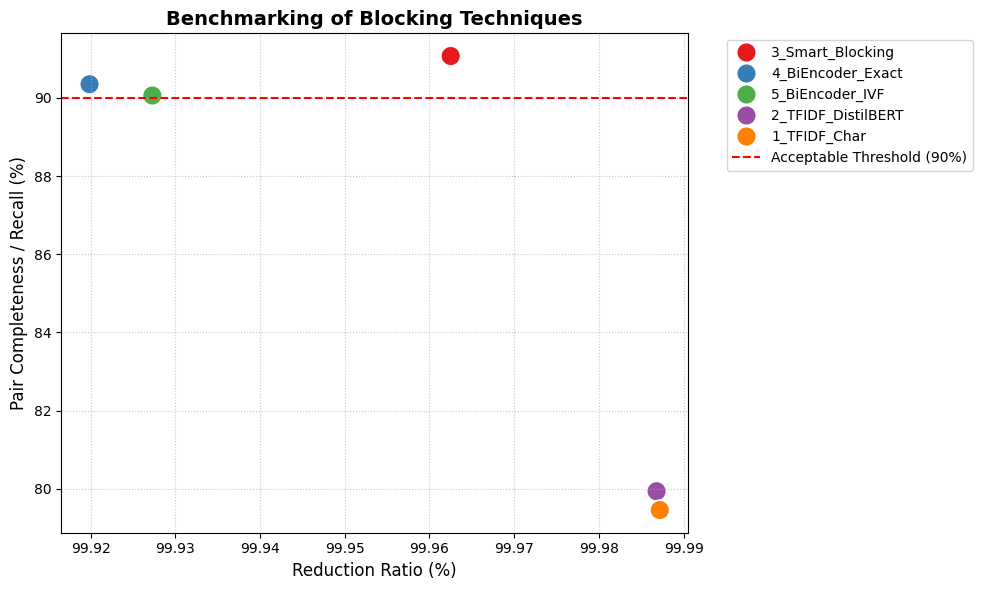

In [6]:
TOTAL_ENTITIES = len(df_all)
country_counts = df_all['cntry'].value_counts()
TOTAL_POSSIBLE_PAIRS = sum((n * (n - 1)) / 2 for n in country_counts) # candidate pairs share same country

def evaluate_results(folder_path, gt_positives, execution_times):    
    results_stats = []
    files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    print(f"\nEvaluating {len(files)} files...")
    
    for file in files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path, dtype=str)
        cols = df.columns.tolist()
            
        generated_pairs = set()
        for _, row in df.iterrows():
            id1 = str(row['id_1']).strip()
            id2 = str(row['id_2']).strip()
            if id1 and id2 and str(id1).lower() != 'nan' and str(id2).lower() != 'nan':
                generated_pairs.add(tuple(sorted([id1, id2])))
                
        total_candidates = len(generated_pairs)
        
        true_positives = len(generated_pairs.intersection(gt_positives))
        
        # Pair Completeness = TP / Total Positives (Recall)
        pair_completeness = true_positives / len(gt_positives) if len(gt_positives) > 0 else 0
        
        # Reduction Ratio = 1 - (Generated Candidates / Posible Pairs)
        reduction_ratio = 1 - (total_candidates / TOTAL_POSSIBLE_PAIRS)
        algo_name = file.replace('.csv', '')
        time_taken = execution_times.get(algo_name, 0.0)
        
        results_stats.append({
            'Algorithm/File': algo_name,
            'Time (s)': round(time_taken, 1),
            'Total Generated Candidates': total_candidates,
            'True Positives (TP)': true_positives,
            'Pair Completeness (Recall)': round(pair_completeness * 100, 2), # %
            'Reduction Ratio': round(reduction_ratio * 100, 6) # %
        })
        
        print(f"  > {file}: {total_candidates} pairs -> {true_positives} true positives.")

    return pd.DataFrame(results_stats)

def plot_benchmark(df_stats):
    if df_stats.empty:
        return
        
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df_stats, 
        x='Reduction Ratio', 
        y='Pair Completeness (Recall)', 
        hue='Algorithm/File',
        s=200,
        palette='Set1'
    )
    
    plt.axhline(y=90, color='r', linestyle='--', label='Acceptable Threshold (90%)')
    
    plt.title('Benchmarking of Blocking Techniques', fontsize=14, fontweight='bold')
    plt.xlabel('Reduction Ratio (%)', fontsize=12)
    plt.ylabel('Pair Completeness / Recall (%)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plot_path = 'blocking_benchmark_plot.png'
    # plt.savefig(plot_path)
    plt.show()
    
    
df_results = evaluate_results(OUTPUT_FOLDER, gt_positives, execution_times)
df_results = df_results.sort_values(by=['Pair Completeness (Recall)', 'Reduction Ratio'], ascending=[False, False])

print("\n" + "="*50)
print("FINAL BENCHMARK RESULTS")
print("="*50)
print(df_results.to_string(index=False))

plot_benchmark(df_results)

## Check exact name matches VS fuzzy matches

In [7]:
import json
import pandas as pd

def prepare_benchmark_from_jsonl(gt_path):
    print("1. Loading Ground Truth and reconstructing entities...")
    gt_trivial = set() # Identical names
    gt_hard = set()    # Different names (fuzzy/semantic)
    entities_dict = {}
    
    with open(gt_path, 'r', encoding='utf-8') as f:
        for line in f:
            record = json.loads(line)
            
            id1 = str(record.get('RIAD_CD_1', '')).strip()
            id2 = str(record.get('RIAD_CD_2', '')).strip()
            
            nm1 = str(record.get('NM_ENTTY_1', '')).strip().lower()
            nm2 = str(record.get('NM_ENTTY_2', '')).strip().lower()
            
            if id1 and id1 not in entities_dict:
                entities_dict[id1] = {
                    'entty_riad_cd': id1, 'nm_entty': nm1,
                    'cty': str(record.get('CTY_1', '')).strip(),
                    'strt': str(record.get('STRT_1', '')).strip(),
                    'pstl_cd': str(record.get('PSTL_CD_1', '')).strip(),
                    'cntry': id1[:2]
                }
            if id2 and id2 not in entities_dict:
                entities_dict[id2] = {
                    'entty_riad_cd': id2, 'nm_entty': nm2,
                    'cty': str(record.get('CTY_2', '')).strip(),
                    'strt': str(record.get('STRT_2', '')).strip(),
                    'pstl_cd': str(record.get('PSTL_CD_2', '')).strip(),
                    'cntry': id2[:2]
                }
                
            # --- Register Stratified True Positives ---
            if record.get('ASSESSMENT') == 'y':
                if id1 and id2:
                    pair = tuple(sorted([id1, id2]))
                    # TIER 1: Trivial vs TIER 2: Hard
                    if nm1 == nm2:
                        gt_trivial.add(pair)
                    else:
                        gt_hard.add(pair)
                    
    df_universe = pd.DataFrame(list(entities_dict.values()))
    df_universe['blocking_text'] = df_universe['nm_entty'].str.lower().str.strip() # + ' ' + df_universe['strt'].str.lower().str.strip() + ' ' + df_universe['cty'].str.lower().str.strip()
    
    print(f"   > Total unique entities: {len(df_universe)}")
    print(f"   > TRIVIAL Duplicates (Exact Match): {len(gt_trivial)}")
    print(f"   > HARD Duplicates (Fuzzy/Semantic): {len(gt_hard)}")
    print(f"   > Total Duplicates: {len(gt_trivial) + len(gt_hard)}")
    
    return df_universe, gt_trivial, gt_hard

df_all, gt_trivial, gt_hard = prepare_benchmark_from_jsonl(GROUND_TRUTH_PATH)

1. Loading Ground Truth and reconstructing entities...
   > Total unique entities: 83236
   > TRIVIAL Duplicates (Exact Match): 7539
   > HARD Duplicates (Fuzzy/Semantic): 7472
   > Total Duplicates: 15011



Evaluating 5 files...
  > 1_TFIDF_Char: Found 7394 trivial and 4533 hard.
  > 4_BiEncoder_Exact: Found 7450 trivial and 6112 hard.
  > 2_TFIDF_DistilBERT: Found 7399 trivial and 4601 hard.
  > 5_BiEncoder_IVF: Found 7448 trivial and 6071 hard.
  > 3_Smart_Blocking: Found 7456 trivial and 6215 hard.

FINAL BENCHMARK RESULTS
    Algorithm/File  Time (s)  Total Candidates Generated  GLOBAL Pair Completeness (%)  TRIVIAL Recall (%)  HARD Recall (%)  Reduction Ratio (%)
  3_Smart_Blocking      96.6                      131811                         91.07               98.90            83.18            99.962504
 4_BiEncoder_Exact     103.2                      281655                         90.35               98.82            81.80            99.919879
   5_BiEncoder_IVF     100.9                      255591                         90.06               98.79            81.25            99.927293
2_TFIDF_DistilBERT      25.9                       46399                         79.94        

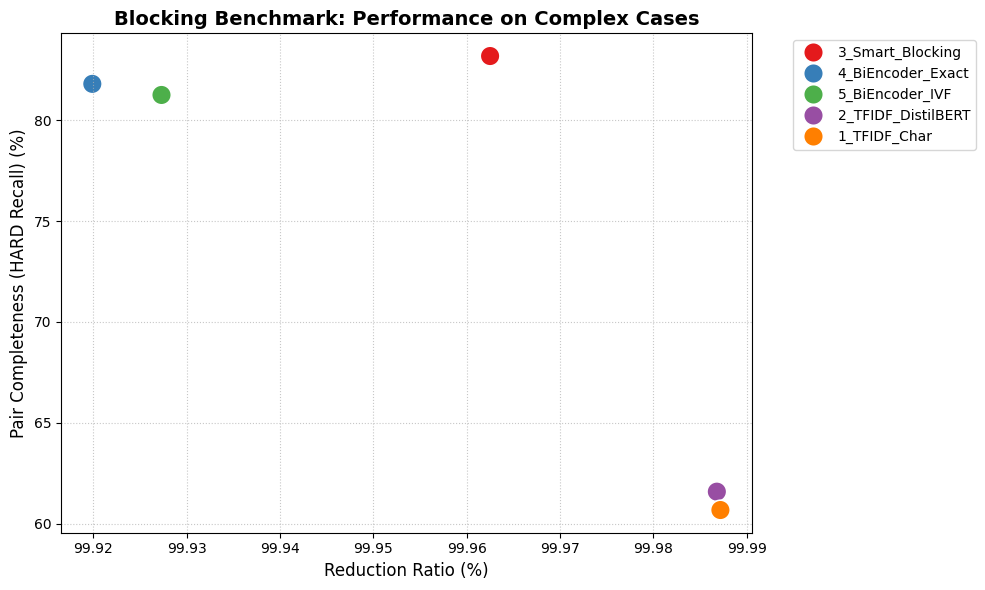

In [8]:
def evaluate_results(folder_path, gt_trivial, gt_hard, execution_times):    
    results_stats = []
    total_gt = len(gt_trivial) + len(gt_hard)

    files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    print(f"\nEvaluating {len(files)} files...")
    
    for file in files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path, dtype=str)
            
        generated_pairs = set()
        for _, row in df.iterrows():
            id1 = str(row['id_1']).strip()
            id2 = str(row['id_2']).strip()
            if id1 and id2 and str(id1).lower() != 'nan' and str(id2).lower() != 'nan':
                generated_pairs.add(tuple(sorted([id1, id2])))
                
        total_candidates = len(generated_pairs)
        
        tp_trivial = len(generated_pairs.intersection(gt_trivial))
        tp_hard = len(generated_pairs.intersection(gt_hard))
        tp_total = tp_trivial + tp_hard
        
        # Pair Completeness = TP / Total Positives (Recall)
        recall_trivial = tp_trivial / len(gt_trivial) if len(gt_trivial) > 0 else 0
        recall_hard = tp_hard / len(gt_hard) if len(gt_hard) > 0 else 0
        recall_global = tp_total / total_gt if total_gt > 0 else 0
        
        # Reduction Ratio = 1 - (Generated Candidates / Posible Pairs)
        reduction_ratio = 1 - (total_candidates / TOTAL_POSSIBLE_PAIRS)
        algo_name = file.replace('.csv', '')
        time_taken = execution_times.get(algo_name, 0.0)        
        
        results_stats.append({
            'Algorithm/File': algo_name,
            'Time (s)': round(time_taken, 1),
            'Total Candidates Generated': total_candidates,
            'GLOBAL Pair Completeness (%)': round(recall_global * 100, 2),
            'TRIVIAL Recall (%)': round(recall_trivial * 100, 2), 
            'HARD Recall (%)': round(recall_hard * 100, 2),
            'Reduction Ratio (%)': round(reduction_ratio * 100, 6)
        })
        
        print(f"  > {algo_name}: Found {tp_trivial} trivial and {tp_hard} hard.")

    return pd.DataFrame(results_stats)

df_results = evaluate_results(OUTPUT_FOLDER, gt_trivial, gt_hard, execution_times)

df_results = df_results.sort_values(by=['HARD Recall (%)', 'Reduction Ratio (%)'], ascending=[False, False])

def plot_benchmark(df_stats):
    if df_stats.empty:
        return
        
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df_stats, 
        x='Reduction Ratio (%)', 
        y='HARD Recall (%)',
        hue='Algorithm/File',
        s=200,
        palette='Set1'
    )
    
    plt.title('Blocking Benchmark: Performance on Complex Cases', fontsize=14, fontweight='bold')
    plt.xlabel('Reduction Ratio (%)', fontsize=12)
    plt.ylabel('Pair Completeness (HARD Recall) (%)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plot_path = 'blocking_benchmark_plot.png'
    # plt.savefig(plot_path)
    print(f"\n[SUCCESS] Plot saved to {plot_path}")
    plt.show()

print("\n" + "="*50)
print("FINAL BENCHMARK RESULTS")
print("="*50)
print(df_results.to_string(index=False))

plot_benchmark(df_results)

## Blocking benchmark different hyperparameters

In [10]:
import itertools
OUTPUT_FOLDER_2 = 'blocking_benchmark'
TOP_KS = [10, 20, 50] 
algorithms_grid = {}
for k in TOP_KS:

    algorithms_grid[f'1_TFIDF_Char_K{k}_TH0.60'] = lambda df, k=k: run_tfidf_char_blocking(df, top_k=k, threshold=0.60)
    algorithms_grid[f'1_TFIDF_Char_K{k}_TH0.70'] = lambda df, k=k: run_tfidf_char_blocking(df, top_k=k, threshold=0.70)
    algorithms_grid[f'1_TFIDF_Char_K{k}_TH0.80'] = lambda df, k=k: run_tfidf_char_blocking(df, top_k=k, threshold=0.80)

    algorithms_grid[f'1_TFIDF__DistilBERT_K{k}_TH0.60'] = lambda df, k=k: run_tfidf_bert_blocking(df, top_k=k, threshold=0.60)
    algorithms_grid[f'1_TFIDF__DistilBERT_K{k}_TH0.70'] = lambda df, k=k: run_tfidf_bert_blocking(df, top_k=k, threshold=0.70)
    algorithms_grid[f'1_TFIDF__DistilBERT_K{k}_TH0.80'] = lambda df, k=k: run_tfidf_bert_blocking(df, top_k=k, threshold=0.80)

    algorithms_grid[f'3_Smart_K{k}_Cos0.4_Jaro0.75'] = lambda df, k=k: run_smart_blocking(df, top_k=k, min_cosine=0.4, min_jaro=0.75)
    algorithms_grid[f'3_Smart_K{k}_Cos0.4_Jaro0.80'] = lambda df, k=k: run_smart_blocking(df, top_k=k, min_cosine=0.4, min_jaro=0.80)
    algorithms_grid[f'3_Smart_K{k}_Cos0.4_Jaro0.85'] = lambda df, k=k: run_smart_blocking(df, top_k=k, min_cosine=0.4, min_jaro=0.85)

    algorithms_grid[f'4_BiEncoder_K{k}_TH0.70'] = lambda df, k=k: run_neural_exact(df, top_k=k, min_score=0.70)
    algorithms_grid[f'4_BiEncoder_K{k}_TH0.75'] = lambda df, k=k: run_neural_exact(df, top_k=k, min_score=0.75)
    algorithms_grid[f'4_BiEncoder_K{k}_TH0.80'] = lambda df, k=k: run_neural_exact(df, top_k=k, min_score=0.80)

algorithms_grid['5_BiEncoder_IVF_K50_TH0.75'] = lambda df: run_neural_ivf(df, top_k=50, min_score=0.75)

execution_times = {name: 0.0 for name in algorithms_grid.keys()}
print(f"Running Grid Search for {len(algorithms_grid)} configurations...")
for name in algorithms_grid.keys(): execution_times[name] = 0.0
print(f"Running Benchmark for {len(COUNTRIES)} countries...\n")

for algo_name, algo_func in algorithms_grid.items():
    print(f"Starting: {algo_name}")
    all_algo_results = []
    t0_algo = time.time()
    
    for country in tqdm(COUNTRIES, desc=algo_name, leave=False):
        country_df = df_all[df_all['cntry'] == country].copy().reset_index(drop=True)
        
        matches = algo_func(country_df)
        if matches:
            all_algo_results.extend(matches)
            
    t1_algo = time.time()
    execution_times[algo_name] = t1_algo - t0_algo
    
    # Save results
    if all_algo_results:
        df_res = pd.DataFrame(all_algo_results)
        path = os.path.join(OUTPUT_FOLDER_2, f"{algo_name}.csv")
        df_res.to_csv(path, index=False)
        print(f"  > Generated {len(df_res)} pairs in {execution_times[algo_name]:.1f}s")
    else:
        print(f"  > No pairs generated.")

Running Grid Search for 37 configurations...
Running Benchmark for 163 countries...

Starting: 1_TFIDF_Char_K10_TH0.60


1_TFIDF_Char_K10_TH0.60:   0%|          | 0/163 [00:00<?, ?it/s]

  > Generated 88050 pairs in 30.1s
Starting: 1_TFIDF_Char_K10_TH0.70


1_TFIDF_Char_K10_TH0.70:   0%|          | 0/163 [00:00<?, ?it/s]

  > Generated 59863 pairs in 26.7s
Starting: 1_TFIDF_Char_K10_TH0.80


...

  > Generated 436406 pairs in 118.3s
Starting: 4_BiEncoder_K50_TH0.80


4_BiEncoder_K50_TH0.80:   0%|          | 0/163 [00:00<?, ?it/s]

  > Generated 256605 pairs in 106.0s
Starting: 5_BiEncoder_IVF_K50_TH0.75


5_BiEncoder_IVF_K50_TH0.75:   0%|          | 0/163 [00:00<?, ?it/s]

  > Generated 436406 pairs in 119.8s



FINAL GRID SEARCH RESULTS


,Algorithm/File,Time (s),Total Candidates Generated,GLOBAL Pair Completeness (%),TRIVIAL Recall (%),HARD Recall (%),Reduction Ratio (%),Familia,Family
27,3_Smart_K50_Cos0.4_Jaro0.75,162.5,563612,94.12,99.14,89.05,99.839671,3_Smart,3_Smart
11,3_Smart_K20_Cos0.4_Jaro0.75,126.4,418565,93.66,99.10,88.18,99.880932,3_Smart,3_Smart
22,3_Smart_K50_Cos0.4_Jaro0.80,150.3,306483,93.50,99.08,87.87,99.912816,3_Smart,3_Smart
14,3_Smart_K20_Cos0.4_Jaro0.80,118.8,252427,93.06,99.04,87.02,99.928193,3_Smart,3_Smart
34,4_BiEncoder_K50_TH0.70,137.9,689989,93.01,99.20,86.75,99.803721,4_BiEncoder,4_BiEncoder
20,3_Smart_K10_Cos0.4_Jaro0.75,105.9,310148,92.89,99.06,86.66,99.911773,3_Smart,3_Smart
26,3_Smart_K10_Cos0.4_Jaro0.80,99.8,202249,92.31,99.01,85.56,99.942467,3_Smart,3_Smart
16,3_Smart_K50_Cos0.4_Jaro0.85,142.3,174004,92.13,98.98,85.22,99.950502,3_Smart,3_Smart
7,4_BiEncoder_K20_TH0.70,111.8,406602,91.96,99.08,84.77,99.884335,4_BiEncoder,4_BiEncoder
30,3_Smart_K20_Cos0.4_Jaro0.85,114.5,153857,91.76,98.94,84.52,99.956233,3_Smart,3_Smart


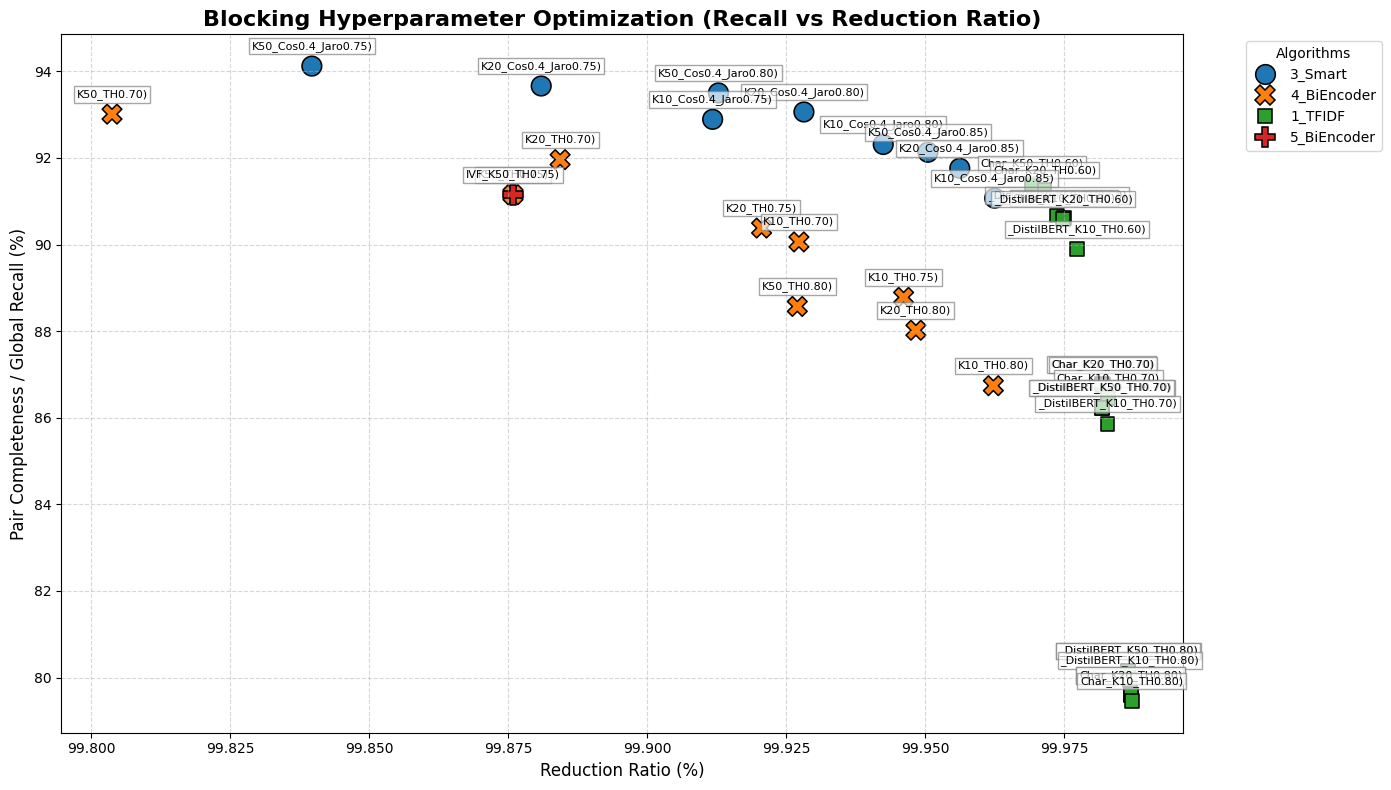

In [23]:
df_grid_results = evaluate_results(OUTPUT_FOLDER_2, gt_trivial, gt_hard, execution_times)
df_grid_results = df_grid_results.sort_values(by=['GLOBAL Pair Completeness (%)', 'Reduction Ratio (%)'], ascending=[False, False])

print("\n" + "="*80)
print("FINAL GRID SEARCH RESULTS")
print("="*80)
display(df_grid_results)
df_grid_results.to_csv('GridSearch_Summary.csv', index=False)

def plot_grid_search(df_stats):
    if df_stats.empty: return
        
    plt.figure(figsize=(14, 8))
    # Translated 'Familia' to 'Family'
    df_stats['Family'] = df_stats['Algorithm/File'].apply(lambda x: "_".join(x.split('_')[:2]))
    sns.scatterplot(
        data=df_stats, 
        x='Reduction Ratio (%)', 
        y='GLOBAL Pair Completeness (%)', 
        hue='Family',
        style='Family',
        s=200, 
        palette='tab10',
        edgecolor='black'
    )
    
    for i in range(df_stats.shape[0]):
        x_val = df_stats['Reduction Ratio (%)'].iloc[i]
        y_val = df_stats['GLOBAL Pair Completeness (%)'].iloc[i]
        algo_full = df_stats['Algorithm/File'].iloc[i]
        time_val = df_stats['Time (s)'].iloc[i]
        
        config_label = algo_full.split('_', 2)[-1] if len(algo_full.split('_')) > 2 else algo_full
        label_text = f"{config_label})"
        
        plt.text(x_val, y_val + 0.4, label_text, 
                 horizontalalignment='center', size=8, color='black',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', pad=2))
    
    plt.title('Blocking Hyperparameter Optimization (Recall vs Reduction Ratio)', fontsize=16, fontweight='bold')
    plt.xlabel('Reduction Ratio (%)', fontsize=12)
    plt.ylabel('Pair Completeness / Global Recall (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Algorithms")
    plt.tight_layout()
    
    plt.savefig('GridSearch_Plot.pdf', dpi=300)
    plt.show()

plot_grid_search(df_grid_results)